In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [26]:
cols = ["area", "perimeter", "compactness", "length", "width", "asymmetry", "groove", "class"]
df = pd.read_csv("seeds_dataset.txt", names=cols, sep="\s+")

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Manish\AppData\Local\Temp\ipykernel_19088\2436742721.py:2: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("seeds_dataset.txt", names=cols, sep="\s+")


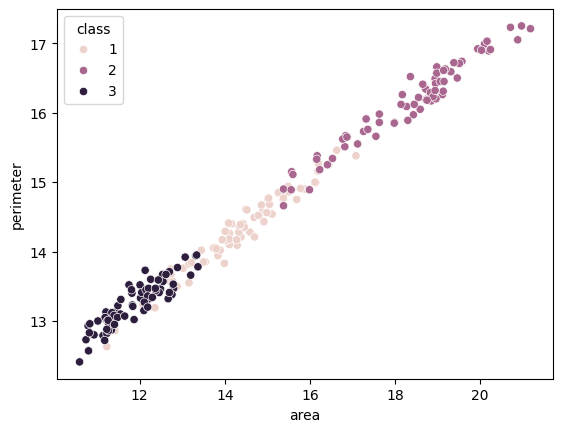

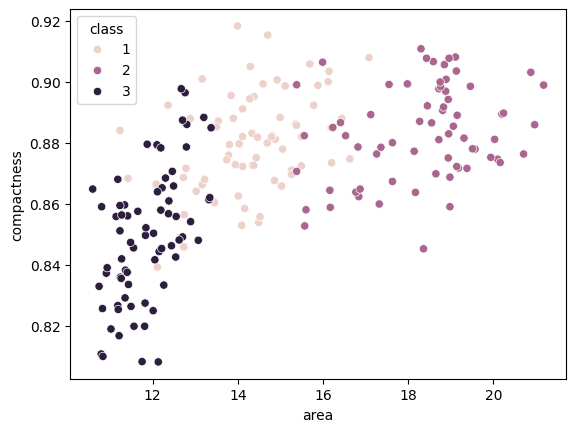

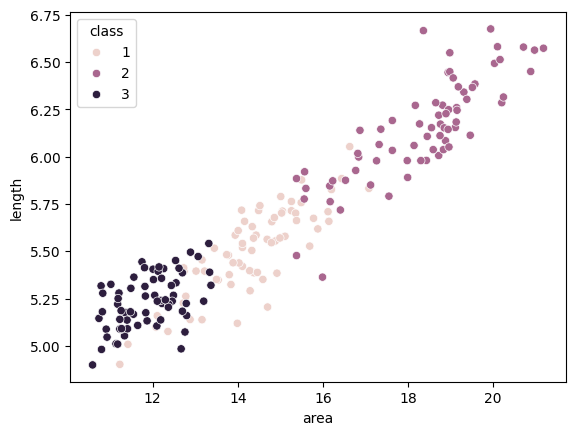

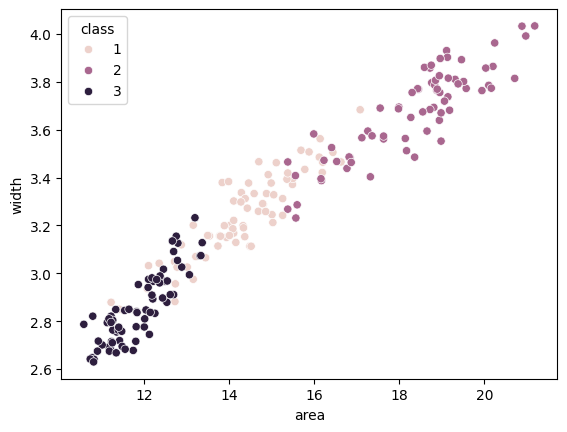

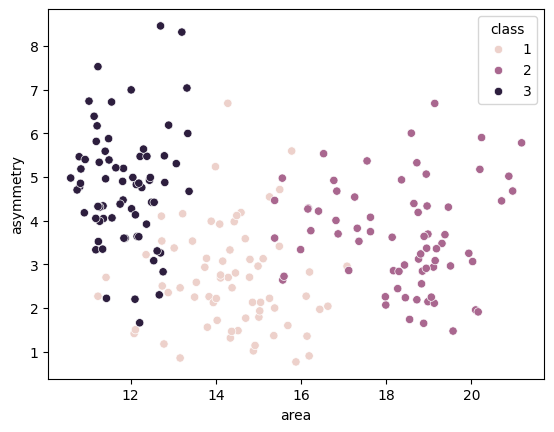

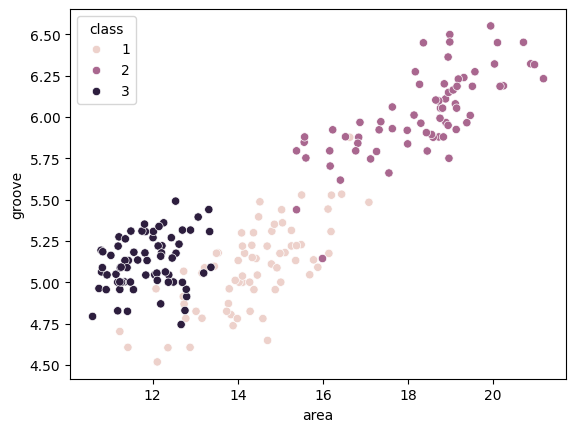

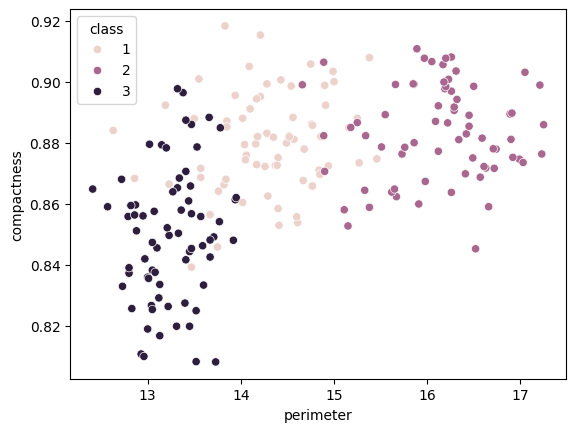

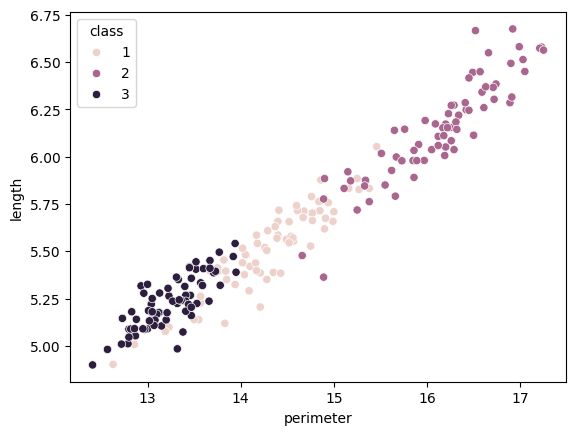

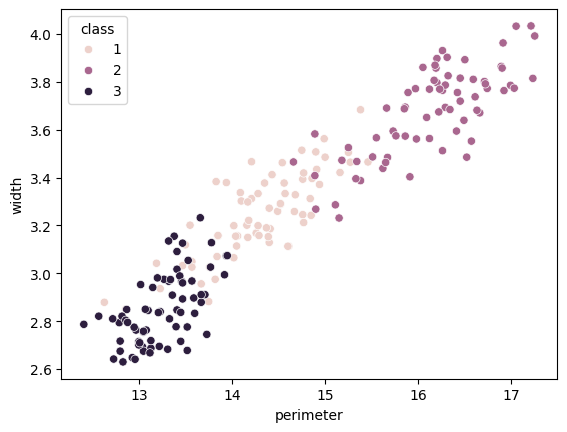

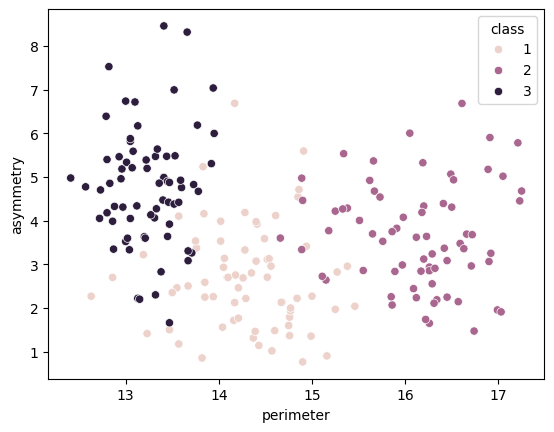

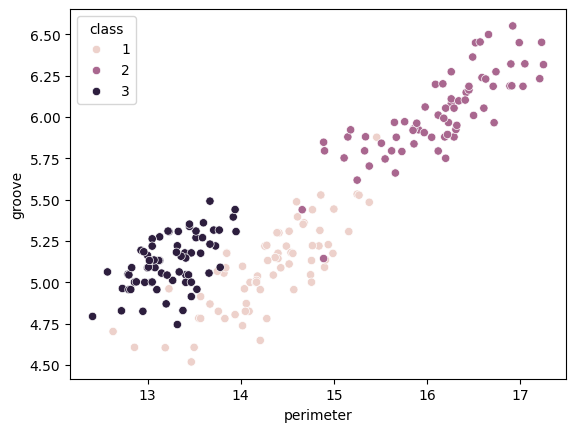

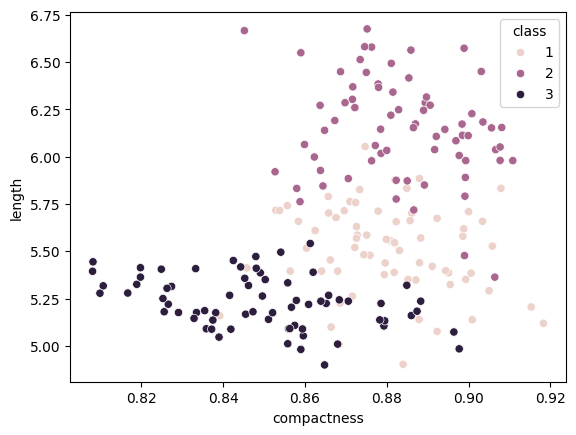

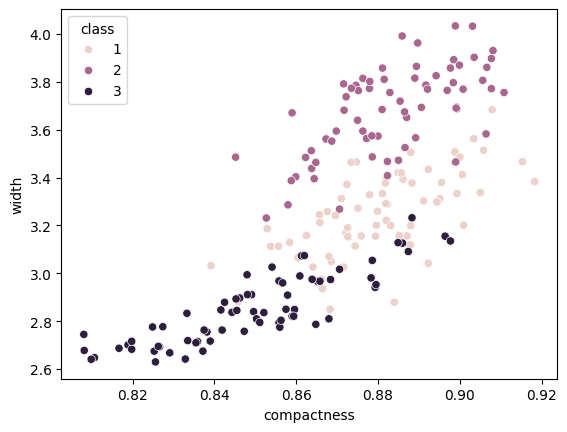

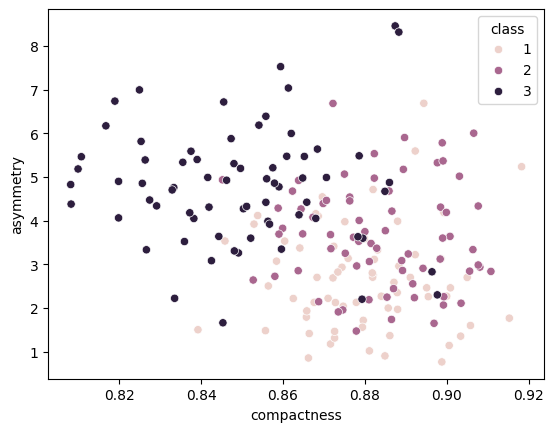

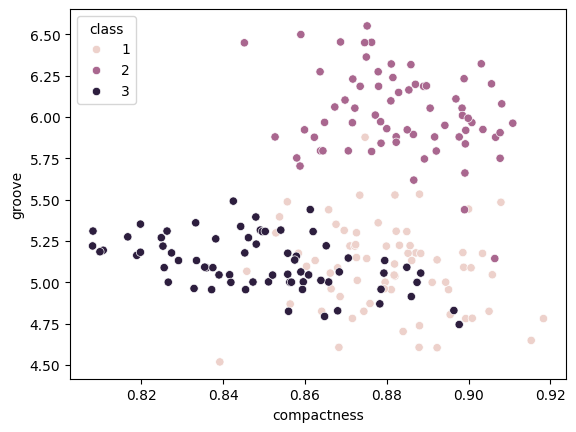

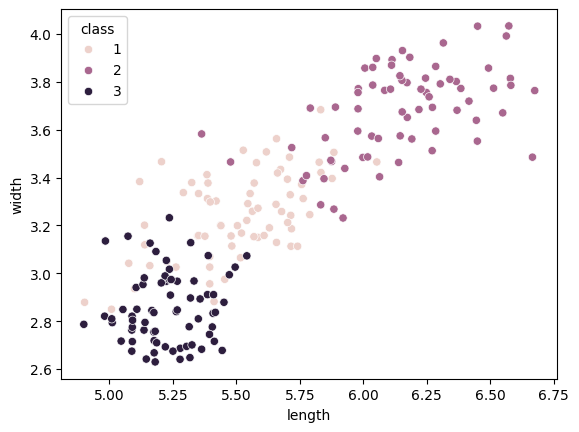

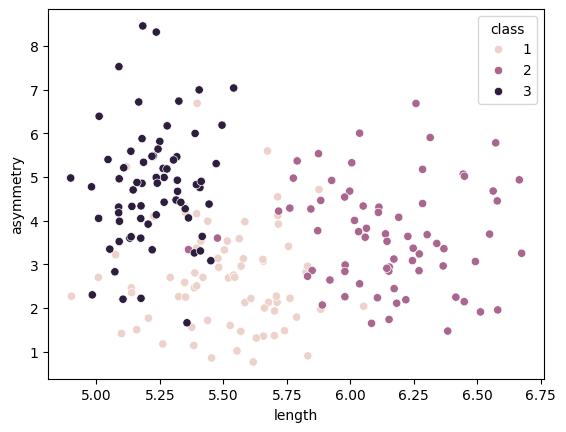

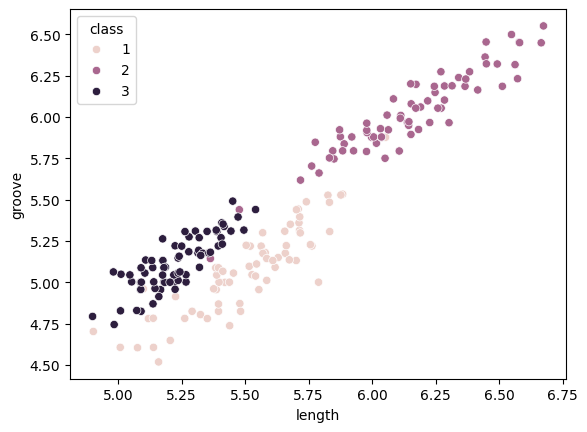

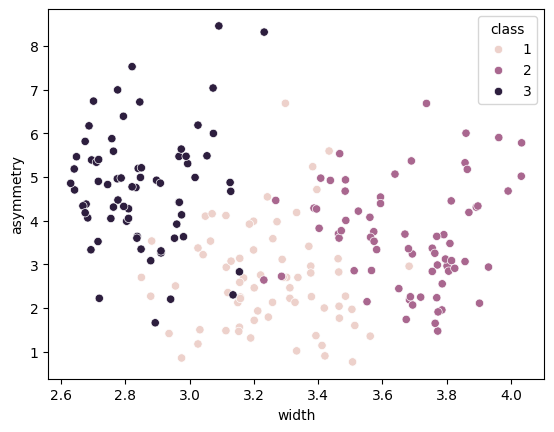

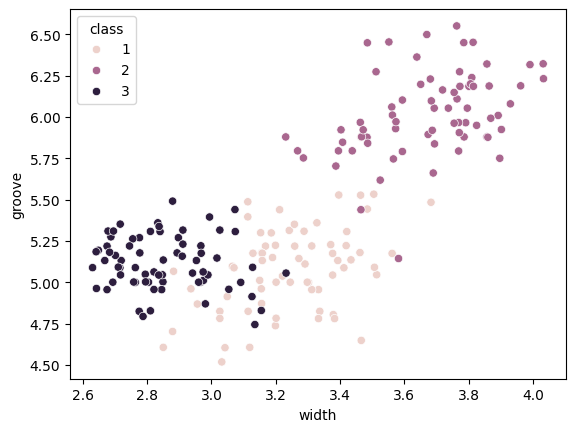

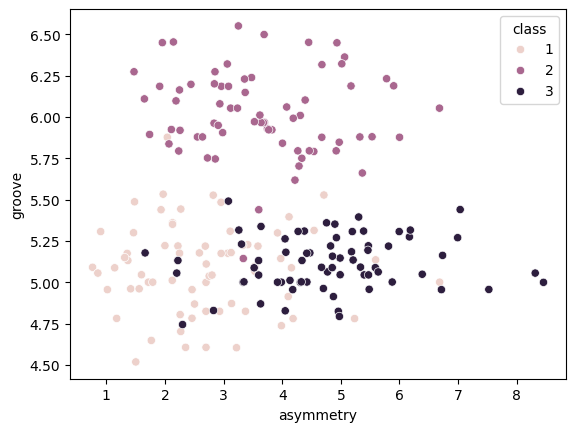

In [27]:
for i in range(len(cols)-1):
  for j in range(i+1, len(cols)-1):
    x_label = cols[i]
    y_label = cols[j]
    sns.scatterplot(x=x_label, y=y_label, data=df, hue='class')
    plt.show()

# Clustering

In [28]:
from sklearn.cluster import KMeans

In [29]:
x = "compactness"
y = "asymmetry"
X = df[[x, y]].values

In [30]:
kmeans = KMeans(n_clusters = 3).fit(X)

In [31]:
clusters = kmeans.labels_

In [32]:
cluster_df = pd.DataFrame(np.hstack((X, clusters.reshape(-1, 1))), columns=[x, y, "class"])

[]

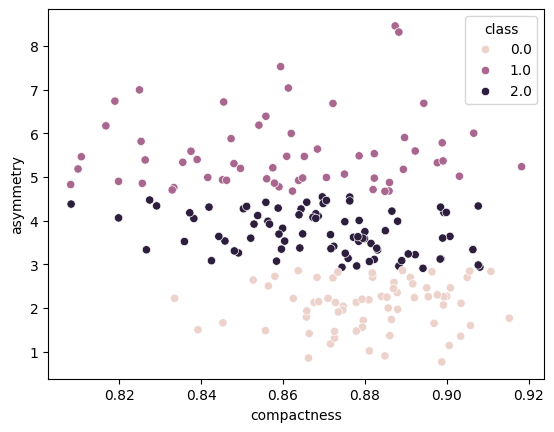

In [33]:
# K Means classes
sns.scatterplot(x=x, y=y, hue='class', data=cluster_df)
plt.plot()

[]

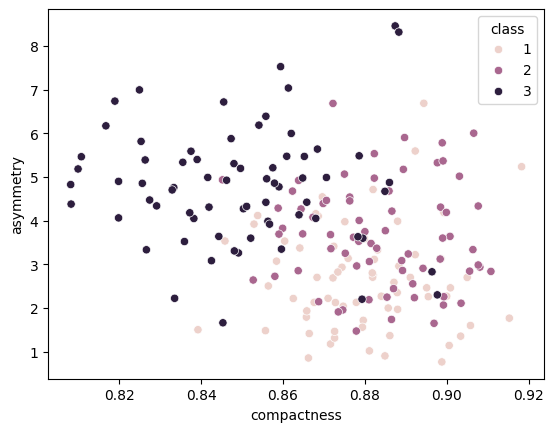

In [34]:
# Original classes
sns.scatterplot(x=x, y=y, hue='class', data=df)
plt.plot()

# # Higher Dimensions

In [35]:
X = df[cols[:-1]].values

In [36]:
kmeans = KMeans(n_clusters = 3).fit(X)
cluster_df = pd.DataFrame(np.hstack((X, kmeans.labels_.reshape(-1, 1))), columns=df.columns)

[]

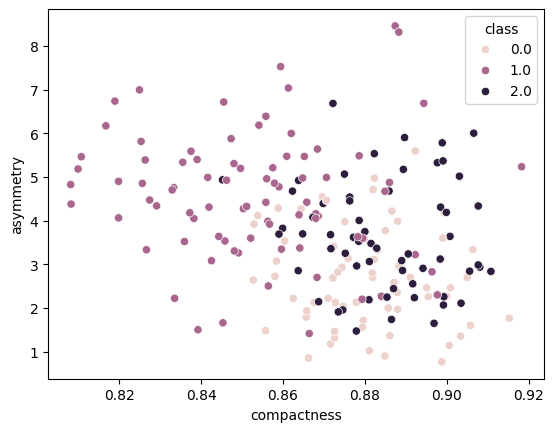

In [37]:
# K Means classes
sns.scatterplot(x=x, y=y, hue='class', data=cluster_df)
plt.plot()

# PCA

In [38]:
from sklearn.decomposition import PCA

In [39]:
pca = PCA(n_components=2)
transformed_x = pca.fit_transform(X)

In [40]:
X.shape

(210, 7)

In [41]:
transformed_x.shape

(210, 2)

In [42]:
transformed_x[:5]

array([[ 0.66344838, -1.41732098],
       [ 0.31566651, -2.68922915],
       [-0.6604993 , -1.13150635],
       [-1.0552759 , -1.62119002],
       [ 1.61999921, -2.18338442]])

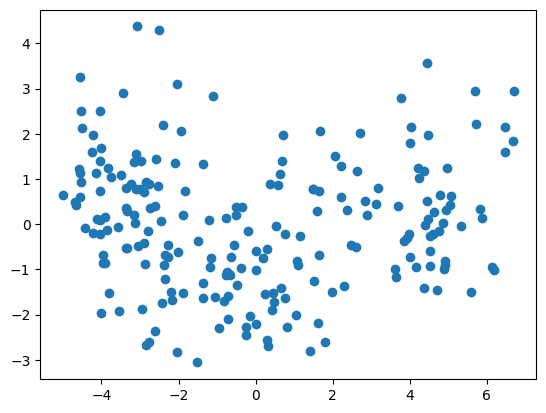

In [43]:
plt.scatter(transformed_x[:,0],transformed_x[:,1])
plt.show()

In [44]:
kmeans_pca_df = pd.DataFrame(np.hstack((transformed_x, kmeans.labels_.reshape(-1, 1))), columns=["pca1", "pca2", "class"])

In [45]:
truth_pca_df = pd.DataFrame(np.hstack((transformed_x, df["class"].values.reshape(-1, 1))), columns=["pca1", "pca2", "class"])

[]

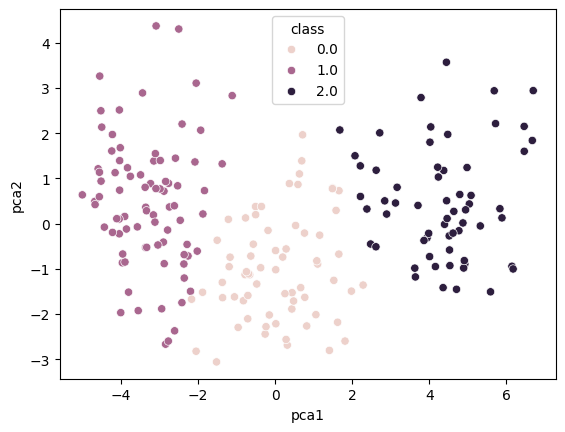

In [46]:
# K Menas Classse
sns.scatterplot(x='pca1',y='pca2',hue='class',data=kmeans_pca_df)
plt.plot()

[]

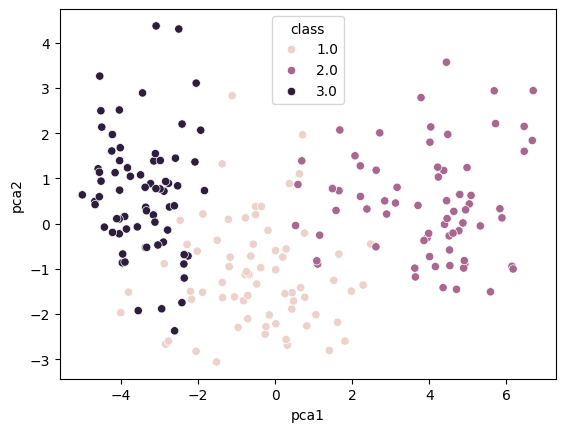

In [47]:
# Truth classes
sns.scatterplot(x="pca1", y="pca2", hue='class', data=truth_pca_df)
plt.plot()